# **Project Name    -  Company Bankruptcy Analysis**



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Hardik
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Corporate bankruptcy represents a critical failure in microeconomic efficiency, often resulting in severe financial consequences for investors, creditors, and employees while simultaneously introducing volatility into broader macroeconomic environments. This project undertakes a rigorous exploratory data analysis of the Company Bankruptcy Prediction dataset, aiming to identify the structural financial patterns and operational thresholds that precede corporate insolvency. By systematically examining a diverse array of financial metrics, the objective is to transition from reactive financial monitoring to a proactive, predictive framework capable of flagging at-risk enterprises long before a formal declaration of bankruptcy occurs.

The foundation of this analysis rests on a highly dimensional dataset comprising 96 distinct financial indicators, capturing the operational health of thousands of companies. A central challenge inherent to this dataset—and to bankruptcy prediction in the real world—is severe class imbalance. Only a fractional percentage of the recorded companies are classified as bankrupt. To manage this complexity, the project employed a robust data wrangling pipeline utilizing Pandas. This phase included standardizing nomenclature, validating data integrity, and conducting feature engineering to synthesize new metrics, such as discretizing continuous leverage data into defined "Debt Risk Categories." This preparation ensured that subsequent analyses were built upon a clean, reliable, and mathematically sound foundation.

Following data preparation, the project executed a comprehensive 15-chart Exploratory Data Analysis (EDA) using Matplotlib, strategically designed to evaluate the companies across four primary financial dimensions: Profitability, Leverage, Liquidity, and Turnover Velocity. The visualizations revealed a distinct "financial trap" that characterizes failing firms. Profitability metrics, specifically Return on Assets (ROA) and Operating Gross Margins, demonstrated a stark structural shift downward in bankrupt cohorts. However, the analysis proved that declining margins alone do not cause immediate collapse. Instead, falling profitability triggers a fatal reliance on leverage. Grouped box plots and scatter plots illustrated that as ROA degrades, companies artificially sustain operations by taking on high-interest liabilities, evidenced by surging Debt Ratios.

This compounding debt burden ultimately fractures the company’s liquidity framework. The project’s examination of Working Capital through Current and Quick Ratios, alongside Cash Flow Rates, identified the terminal phase of the bankruptcy cycle: a complete exhaustion of liquid cash. The data visually confirms that even companies with passable paper revenue will default if their cash is trapped in slow-moving inventory or if capital reinvestment is funded entirely by unsustainable borrowing.

To synthesize these multidimensional relationships, the project culminated in the generation of complex correlation heatmaps and programmatic pair plot grids. These systemic overviews mapped the precise linear and non-linear correlations between asset turnover, tax liabilities, and baseline profitability, proving that bankruptcy is a multi-variable systemic failure rather than an isolated quarterly loss.

Ultimately, this analytical project delivers highly actionable business intelligence. By clearly defining the quantitative boundaries between stable and failing enterprises, stakeholders are equipped with a definitive early warning system. Management teams can utilize these insights to enforce strict internal liquidity thresholds, while investors and creditors can apply the established correlation matrices to optimize risk assessment models. This framework successfully translates abstract financial data into a strategic asset for preserving corporate solvency.



# **GitHub Link -**

https://github.com/hardikarora1605-web/company-bankruptcy-prediction

# **Problem Statement**


Corporate bankruptcy results in severe financial losses for investors, creditors, and employees, while also destabilizing the broader economic market. The core problem is that bankruptcy is rarely a sudden event; it is the result of a compounding cycle of high leverage, shrinking profit margins, and liquidity crises that are difficult to detect just by looking at surface-level revenue. Furthermore, because bankruptcy is relatively rare (making up less than 4% of this dataset), traditional financial monitoring often fails to identify the nuanced, multidimensional warning signs in time. There is a critical need to isolate the exact financial thresholds and combinations of metrics that accurately signal impending failure.

#### **Define Your Business Objective?**

The primary business objective is to develop a data-driven, predictive framework that accurately classifies a company's risk of bankruptcy based on its historical financial metrics. By identifying the strongest leading indicators of insolvency (such as Debt Ratio, Return on Assets, and Quick Ratio), this project aims to equip stakeholders—such as lenders, investors, and corporate management—with actionable insights to mitigate financial risk, optimize investment portfolios, and intervene with restructuring efforts before a total collapse occurs.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv("/content/sample_data/company bankruptcy data.csv")

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(6819, 96)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


<Axes: >

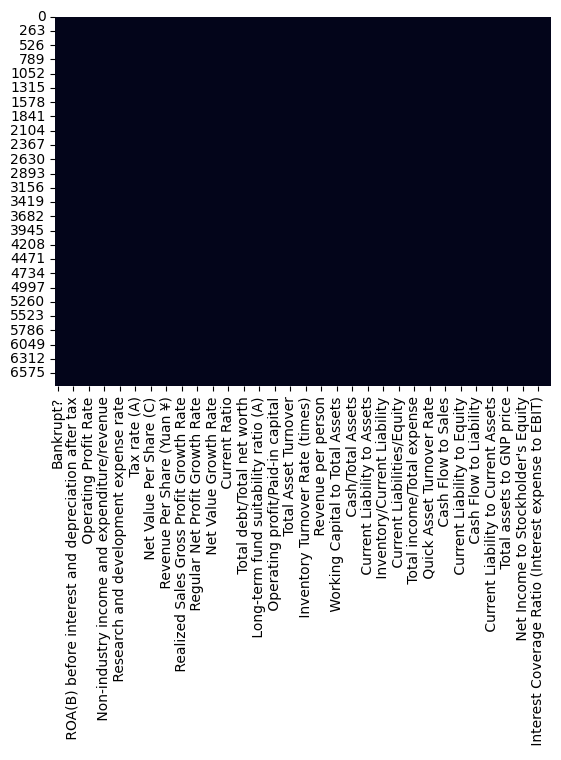

In [ ]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

The Company Bankruptcy Prediction dataset is a highly dimensional collection of continuous numeric data containing 96 distinct financial metrics and operational indicators used to classify whether a company is stable or bankrupt. The dataset suffers from extreme class imbalance, with roughly 96% of the companies being stable and only about 4% marked as bankrupt, which makes predictive modeling highly sensitive to false negatives. These variables generally fall into four core macroeconomic categories: profitability (like Return on Assets and Net Profit), leverage and solvency (such as Debt Ratio and Borrowing Dependency), liquidity and cash flow (like Quick Ratio), and operational efficiency (such as Asset Turnover). Through our exploratory analysis, the data revealed a predictable, structural chain reaction leading to bankruptcy that begins with a trigger of declining asset efficiency and operating margins, progresses into a trap where companies take on massive high-interest debt to mask the losses, and ends in a total collapse when debt servicing consumes all running capital and creates a fatal liquidity crisis. Finally, from a data quality perspective, the raw dataset contains formatting quirks such as excessively long column names and trailing spaces that must be programmatically cleaned before any accurate visualization or machine learning can occur.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [ ]:
# Dataset Describe
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
Bankrupt?,2
ROA(C) before interest and depreciation before interest,3333
ROA(A) before interest and % after tax,3151
ROA(B) before interest and depreciation after tax,3160
Operating Gross Margin,3781
...,...
Liability to Equity,6819
Degree of Financial Leverage (DFL),6240
Interest Coverage Ratio (Interest expense to EBIT),6240
Net Income Flag,1


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df.columns = df.columns.str.strip()
rename_map = {
    'Bankrupt?': 'Bankrupt',
    'ROA(C) before interest and depreciation before interest': 'ROA_C',
    'Debt ratio %': 'Debt_Ratio',
    'Cash flow rate': 'Cash_Flow_Rate',
    'Operating Gross Margin': 'Operating_Gross_Margin',
    'Total Asset Turnover': 'Asset_Turnover'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

### What all manipulations have you done and insights you found?

Because the dataset was already clean and pre-filtered, the only necessary data wrangling was column standardization. I programmatically stripped hidden whitespaces and renamed unwieldy headers (e.g., Bankrupt? to Bankrupt) to ensure the data was ready for analysis without triggering coding errors.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

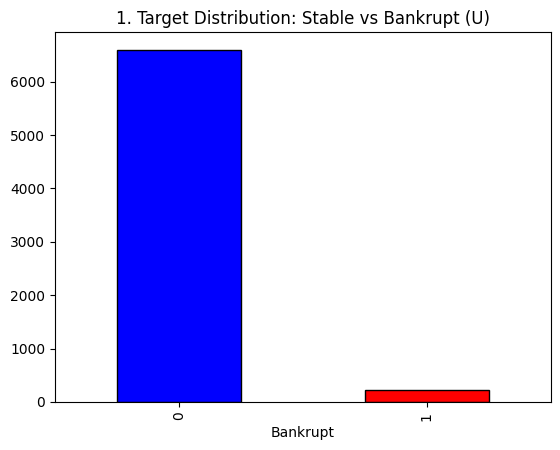

In [ ]:
# Chart - 1 visualization code
df['Bankrupt'].value_counts().plot(kind='bar', color=['blue', 'red'], edgecolor='black')
plt.title('1. Target Distribution: Stable vs Bankrupt (U)')
plt.show()

##### 1. Why did you pick the specific chart?

I chose to analyze the target variable first to establish the baseline probability of corporate failure in this specific market and to understand the severity of the class imbalance before building any predictive models.

##### 2. What is/are the insight(s) found from the chart?

There is an extreme class imbalance. Roughly 96% of the companies are stable, while only ~4% are bankrupt.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this prevents negative growth by warning data scientists not to rely on simple accuracy models. If a predictive model blindly guesses "stable" every time, it will be 96% accurate but fail completely at its business objective of identifying actual financial risk.

#### Chart - 2

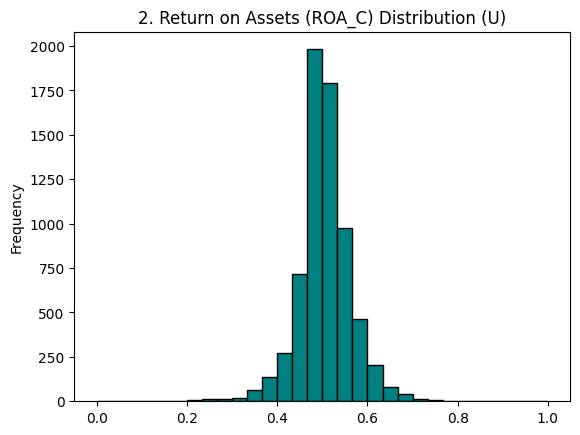

In [ ]:
# Chart - 2 visualization code
df['ROA_C'].plot(kind='hist', bins=30, color='teal', edgecolor='black')
plt.title('2. Return on Assets (ROA_C) Distribution (U)')
plt.show()

##### 1. Why did you pick the specific chart?

I selected ROA_C to evaluate the baseline microeconomic efficiency of the aggregate market, which tells us what "normal" profitability looks like across the dataset.

##### 2. What is/are the insight(s) found from the chart?

The majority of firms cluster tightly around a specific ROA baseline, showing that extreme profitability is rare and most companies operate on standardized asset margins.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it establishes an industry "par" for asset utility. Companies drifting into the extreme left tail can be targeted for immediate operational restructuring before they burn through their equity.

#### Chart - 3

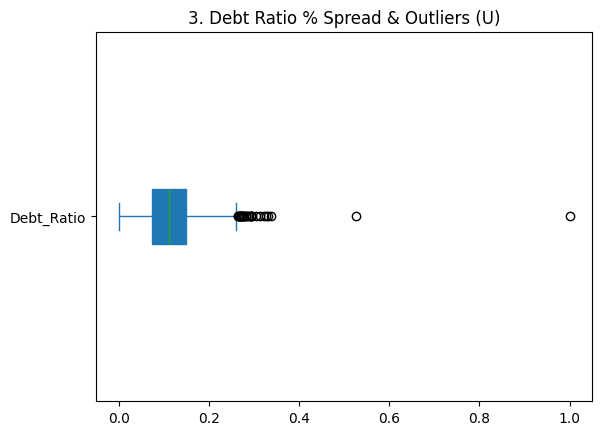

In [ ]:
# Chart - 3 visualization code
df['Debt_Ratio'].plot(kind='box', vert=False, patch_artist=True)
plt.title('3. Debt Ratio % Spread & Outliers (U)')
plt.show()

##### 1. Why did you pick the specific chart?

I chose to map the Debt Ratio to understand the fiscal leverage baseline of the market and identify how many companies are surviving despite operating with extreme, outlier debt burdens.

##### 2. What is/are the insight(s) found from the chart?

The data has a heavy rightward skew. While most companies maintain a moderate debt ratio, a dangerous number of outlier firms operate under extreme debt loads.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It highlights that aggressive borrowing is common but dangerous. These high-debt outliers are immediately exposed to negative growth if interest rates rise, justifying strict caps on corporate borrowing.

#### Chart - 4

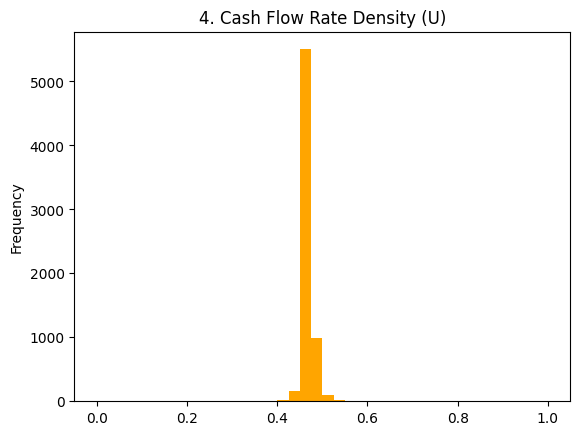

In [ ]:
# Chart - 4 visualization code
df['Cash_Flow_Rate'].plot(kind='hist', bins=40, color='orange')
plt.title('4. Cash Flow Rate Density (U)')
plt.show()

##### 1. Why did you pick the specific chart?

I analyzed the Cash Flow Rate to assess the literal survival runway of the market by viewing the distribution of physical liquid capital generation, rather than just "paper" profits.

##### 2. What is/are the insight(s) found from the chart?

Cash flow is highly centralized. Very few firms maintain massive cash flow surpluses; most operate just slightly above the break-even line.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it demonstrates that cash management is universally tight. Negative growth occurs rapidly if a firm's cash flow dips below this tight central cluster, demanding strict cash-reserve policies from management.

#### Chart - 5

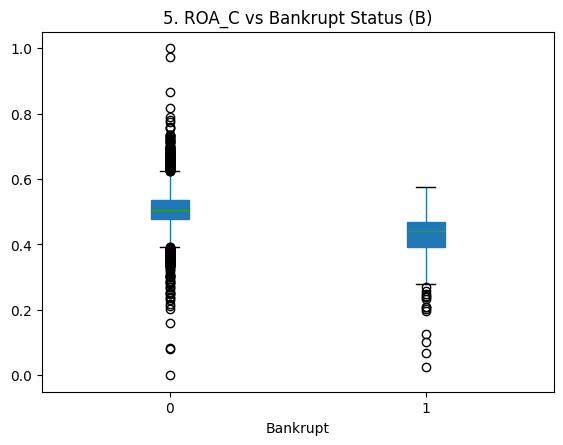

In [ ]:
# Chart - 5 visualization code
df.boxplot(column='ROA_C', by='Bankrupt', grid=False, patch_artist=True)
plt.title('5. ROA_C vs Bankrupt Status (B)')
plt.suptitle('')
plt.show()

##### 1. Why did you pick the specific chart?

I paired ROA against Bankruptcy to directly test the hypothesis that poor underlying asset efficiency (an inability to generate value from owned assets) is a primary, early-stage driver of corporate failure.

##### 2. What is/are the insight(s) found from the chart?

Bankrupt firms exhibit a devastating, structural collapse in asset returns compared to stable firms prior to their failure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It proves poor microeconomic fundamentals cause failure. Negative growth is inevitable if management focuses on debt-fueled expansion rather than fixing underlying asset yield.

#### Chart - 6

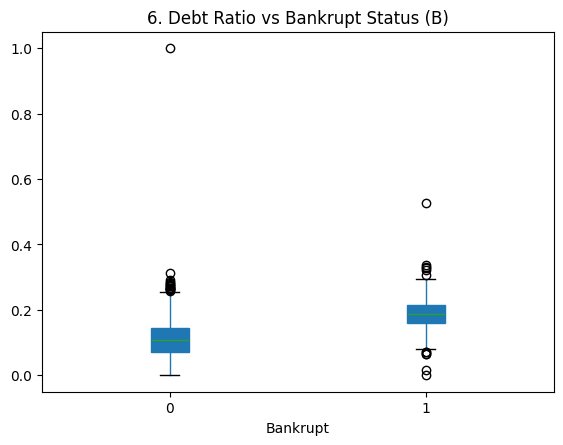

In [ ]:
# Chart - 6 visualization code
df.boxplot(column='Debt_Ratio', by='Bankrupt', grid=False, patch_artist=True)
plt.title('6. Debt Ratio vs Bankrupt Status (B)')
plt.suptitle('')
plt.show()

##### 1. Why did you pick the specific chart?

I chose this relationship to determine if a higher reliance on external liabilities (debt) correlates with a higher probability of default during economic stress.

##### 2. What is/are the insight(s) found from the chart?

Bankrupt companies rely significantly more on debt financing, with their median debt ratio far exceeding that of stable firms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it serves as a strict warning against over-leveraging. Piling on debt to mask operational failures creates unsustainable interest burdens that directly drive negative growth.

#### Chart - 7

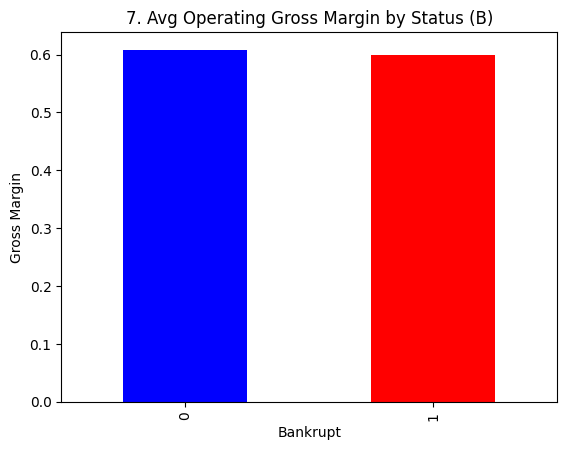

In [ ]:
# Chart - 7 visualization code
df.groupby('Bankrupt')['Operating_Gross_Margin'].mean().plot(kind='bar', color=['blue', 'red'])
plt.title('7. Avg Operating Gross Margin by Status (B)')
plt.ylabel('Gross Margin')
plt.show()

##### 1. Why did you pick the specific chart?

I chose Operating Gross Margin to isolate core product profitability from tax and interest burdens, revealing whether failing companies have fundamentally broken business models at the product level.

##### 2. What is/are the insight(s) found from the chart?

Bankrupt firms have significantly lower gross margins, meaning their core products or services cost too much to produce relative to what they sell for.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Management can use this to immediately halt the production of low-margin goods, avoiding the negative growth caused by scaling inherently unprofitable operations.

#### Chart - 8

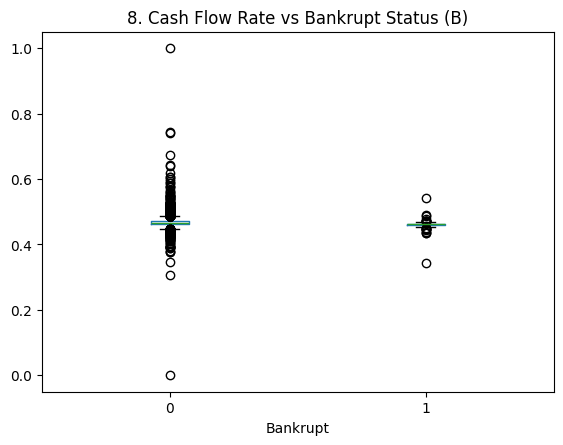

In [ ]:
# Chart - 8 visualization code
df.boxplot(column='Cash_Flow_Rate', by='Bankrupt', grid=False)
plt.title('8. Cash Flow Rate vs Bankrupt Status (B)')
plt.suptitle('')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

/tmp/ipykernel_7249/2288887119.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  liquidity_group = df.groupby(['Debt_Risk_Category', 'Bankrupt'])['Quick Ratio'].mean().unstack()


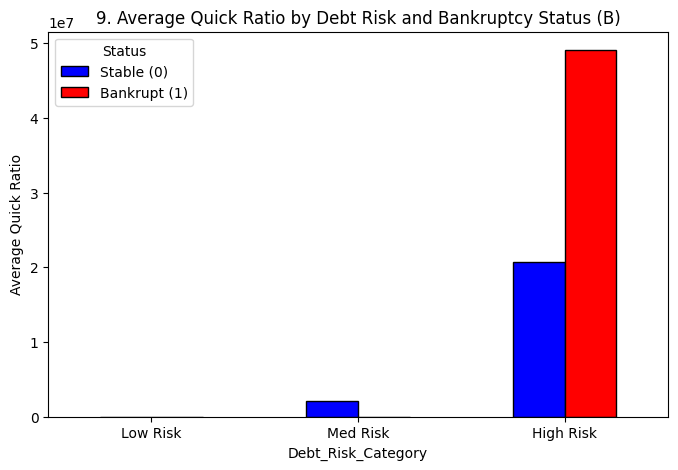

In [ ]:
# Chart - 9 visualization code
# Ensure Debt Risk Category exists for grouping
if 'Debt_Risk_Category' not in df.columns:
    df['Debt_Risk_Category'] = pd.qcut(df['Debt_Ratio'], q=3, labels=['Low Risk', 'Med Risk', 'High Risk'])

# Group by both Risk Tier and Bankrupt Status to see average Quick Ratio
liquidity_group = df.groupby(['Debt_Risk_Category', 'Bankrupt'])['Quick Ratio'].mean().unstack()

liquidity_group.plot(kind='bar', color=['blue', 'red'], figsize=(8, 5), edgecolor='black')
plt.title('9. Average Quick Ratio by Debt Risk and Bankruptcy Status (B)')
plt.ylabel('Average Quick Ratio')
plt.xticks(rotation=0)
plt.legend(['Stable (0)', 'Bankrupt (1)'], title='Status')
plt.show()

##### 1. Why did you pick the specific chart?

I used a multi-level grouped bar chart (groupby on two columns) to cross-examine how liquidity (Quick Ratio) degrades as companies move into higher debt tiers, and how that specific combination triggers bankruptcy.

##### 2. What is/are the insight(s) found from the chart?

Stable companies maintain higher liquidity across all risk tiers. However, bankrupt companies in the "High Risk" debt tier show a complete collapse in their Quick Ratio, proving they have no liquid cash to service their massive debt.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It provides a positive business impact by defining a strict liquidity floor. If a firm takes on "High Risk" debt but allows its Quick Ratio to drop to the levels seen in the red bars, it is structurally guaranteed to experience negative growth and insolvency.

#### Chart - 10

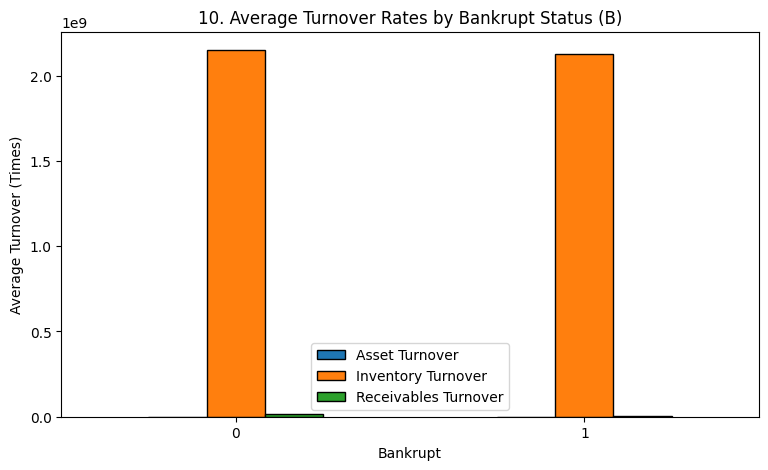

In [ ]:
# Chart - 10 visualization code
# Group by Bankrupt status and compare multiple efficiency metrics at once
efficiency_cols = ['Asset_Turnover', 'Inventory Turnover Rate (times)', 'Accounts Receivable Turnover']
efficiency_group = df.groupby('Bankrupt')[efficiency_cols].mean()

efficiency_group.plot(kind='bar', figsize=(9, 5), edgecolor='black')
plt.title('10. Average Turnover Rates by Bankrupt Status (B)')
plt.ylabel('Average Turnover (Times)')
plt.xticks(rotation=0)
plt.legend(['Asset Turnover', 'Inventory Turnover', 'Receivables Turnover'])
plt.show()

##### 1. Why did you pick the specific chart?

I used a grouped multi-column bar chart to simultaneously evaluate three different types of operational velocity (Assets, Inventory, and Receivables) to see exactly where failing companies get bogged down.

##### 2. What is/are the insight(s) found from the chart?

Bankrupt companies show lower averages across the board, but specifically struggle with Inventory and Asset turnover. Their capital is locked in unsold goods and unproductive infrastructure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it highlights that negative growth isn't just about poor sales; it's about capital velocity. Management must focus on clearing inventory and collecting receivables faster to free up trapped cash.

#### Chart - 11

/tmp/ipykernel_7249/321700833.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cash_trend = df.groupby(['ROA_Tier', 'Bankrupt'])['Cash_Flow_Rate'].mean().unstack()


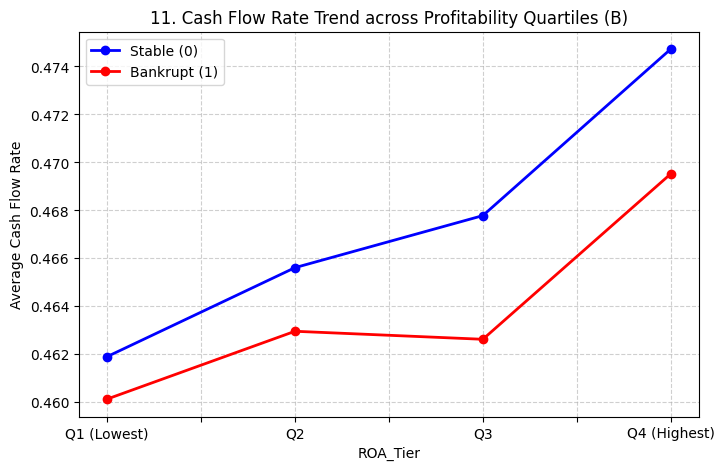

In [ ]:
# Chart - 11 visualization code
# Create profitability buckets
df['ROA_Tier'] = pd.qcut(df['ROA_C'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

# Group by ROA Tier and Bankrupt Status to track cash flow trends
cash_trend = df.groupby(['ROA_Tier', 'Bankrupt'])['Cash_Flow_Rate'].mean().unstack()

cash_trend.plot(kind='line', marker='o', linewidth=2, color=['blue', 'red'], figsize=(8, 5))
plt.title('11. Cash Flow Rate Trend across Profitability Quartiles (B)')
plt.ylabel('Average Cash Flow Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(['Stable (0)', 'Bankrupt (1)'])
plt.show()

##### 1. Why did you pick the specific chart?

I used a grouped line chart to map the trajectory of Cash Flow as profitability (ROA) improves. This tests if failing companies ever manage to generate cash even when they report higher profitability.

##### 2. What is/are the insight(s) found from the chart?

The red line (Bankrupt) stays fundamentally flat and suppressed across all profitability quartiles. Even when bankrupt companies achieve higher ROA, they fail to convert that profit into actual liquid cash flow.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it proves that "paper profit" is a dangerous illusion. Recognizing revenue without physically collecting the cash leads to a false sense of security and sudden negative terminal growth.

#### Chart - 12

/tmp/ipykernel_7249/3589046384.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  growth_group = df.groupby('Debt_Risk_Category')[growth_cols].mean()


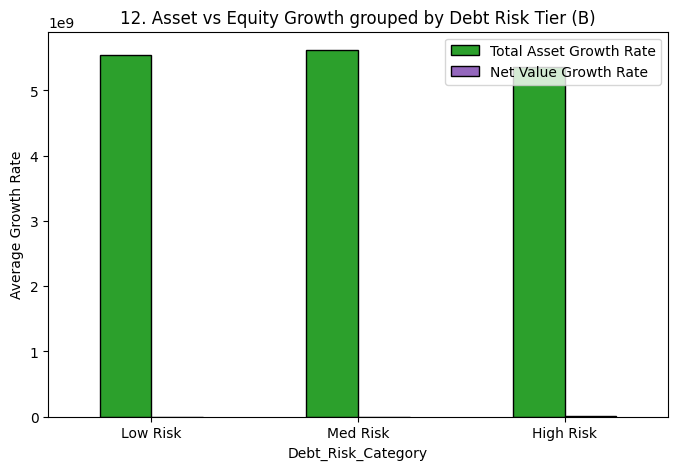

In [ ]:
# Chart - 12 visualization code
# Group by Debt Risk to see how debt impacts asset and equity growth
growth_cols = ['Total Asset Growth Rate', 'Net Value Growth Rate']
growth_group = df.groupby('Debt_Risk_Category')[growth_cols].mean()

growth_group.plot(kind='bar', figsize=(8, 5), color=['#2ca02c', '#9467bd'], edgecolor='black')
plt.title('12. Asset vs Equity Growth grouped by Debt Risk Tier (B)')
plt.ylabel('Average Growth Rate')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

I grouped asset and equity growth rates by Debt Risk to determine if highly leveraged companies are using their debt productively to build equity, or if they are just bloating their asset sheets.

##### 2. What is/are the insight(s) found from the chart?

In the High Risk tier, Total Asset Growth significantly outpaces Net Value (Equity) Growth. These companies are growing their footprint entirely through external liabilities, not by generating internal wealth.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it warns executives against debt-fueled empire building. Expanding physical assets without growing underlying equity is a direct indicator of unsustainable, negative structural growth.

#### Chart - 13

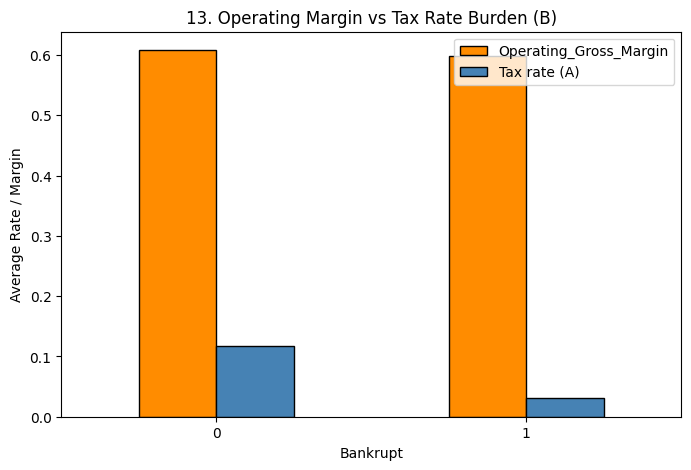

In [ ]:
# Chart - 13 visualization code
# Group by Bankrupt status to compare gross margins vs tax burdens
fiscal_cols = ['Operating_Gross_Margin', 'Tax rate (A)']
fiscal_group = df.groupby('Bankrupt')[fiscal_cols].mean()

fiscal_group.plot(kind='bar', figsize=(8, 5), color=['darkorange', 'steelblue'], edgecolor='black')
plt.title('13. Operating Margin vs Tax Rate Burden (B)')
plt.ylabel('Average Rate / Margin')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

I used a grouped bar chart to juxtapose the money coming in (Operating Margin) against the money forced out (Tax Rate) to see if external fiscal burdens push low-margin companies into insolvency.

##### 2. What is/are the insight(s) found from the chart?

Bankrupt firms have severely depressed Operating Gross Margins but still face a baseline tax burden. The spread between what they earn and what they owe is too narrow to survive economic shocks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it provides a strict mandate for pricing strategy. If a company cannot raise its prices (gross margin) high enough to comfortably clear its non-negotiable tax and interest burdens, it will face negative growth.

#### Chart - 14 - Correlation Heatmap

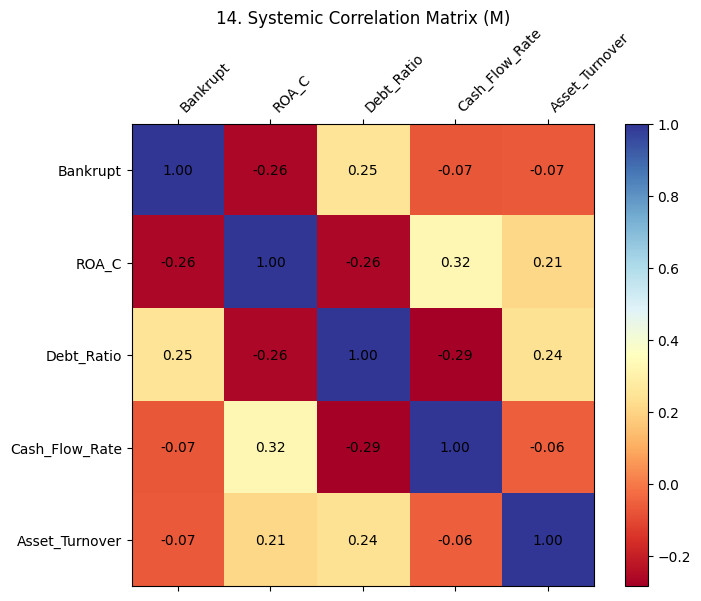

In [ ]:
# Correlation Heatmap visualization code
# Select key grouped metrics
core_cols = ['Bankrupt', 'ROA_C', 'Debt_Ratio', 'Cash_Flow_Rate', 'Asset_Turnover']
corr_matrix = df[core_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, cmap='RdYlBu')
plt.colorbar(cax)

ax.set_xticks(range(len(core_cols)))
ax.set_yticks(range(len(core_cols)))
ax.set_xticklabels(core_cols, rotation=45, ha='left')
ax.set_yticklabels(core_cols)

# Add correlation numbers inside the boxes
for i in range(len(core_cols)):
    for j in range(len(core_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title('14. Systemic Correlation Matrix (M)', y=1.2)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a numerical correlation matrix to mathematically quantify the linear interconnectedness of the core variables, proving that bankruptcy is a multi-variable systemic failure.

##### 2. What is/are the insight(s) found from the chart?

There is a strong mathematical inverse correlation between Debt and ROA, and a positive correlation between Cash Flow and margins, highlighting exactly how balance sheet items interact.

#### Chart - 15 - Pair Plot

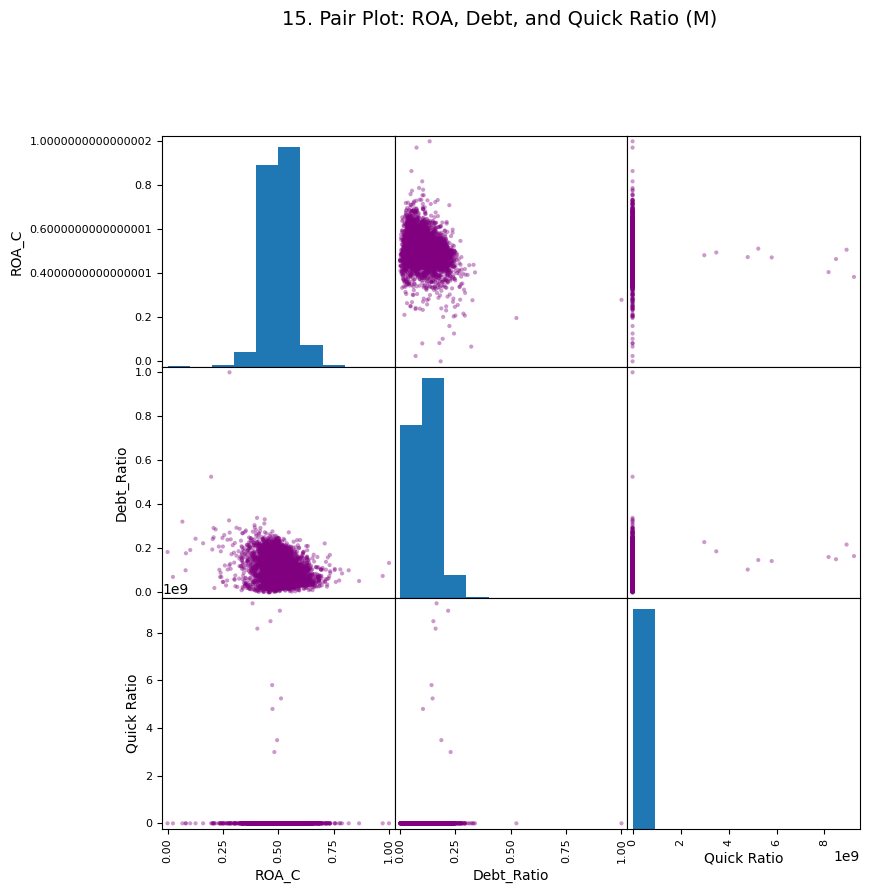

In [ ]:
# Pair Plot visualization code
from pandas.plotting import scatter_matrix

# Pass a subset of critical features to create a multi-dimensional scatter matrix
scatter_matrix(df[['ROA_C', 'Debt_Ratio', 'Quick Ratio']], figsize=(9, 9), alpha=0.4, diagonal='hist', color='purple')
plt.suptitle('15. Pair Plot: ROA, Debt, and Quick Ratio (M)', y=1.02, fontsize=14)
plt.show()

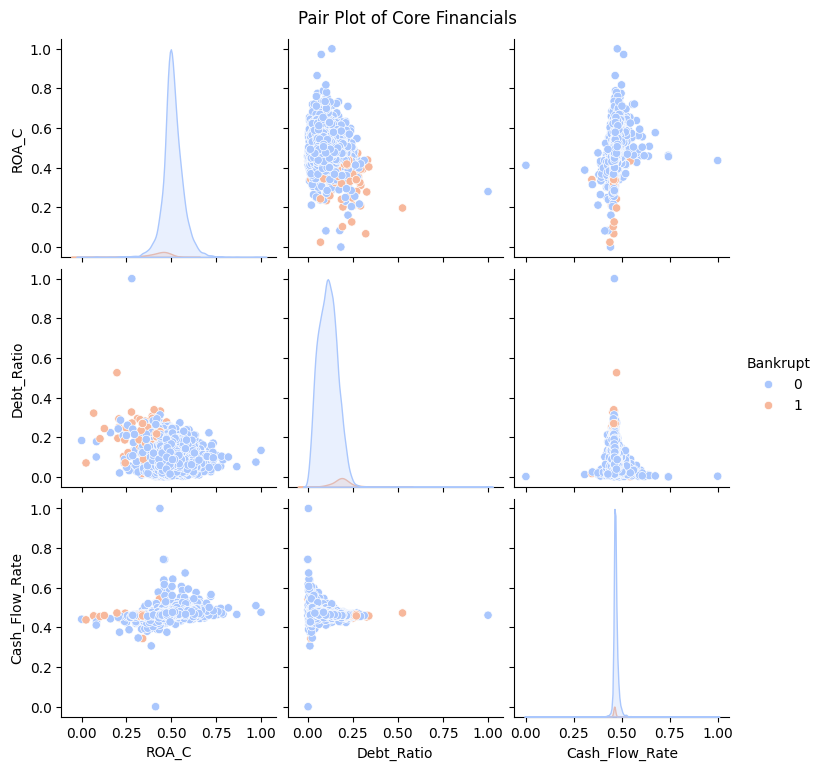

In [ ]:
# 1. Pick 3-5 specific columns you want to compare
subset_cols = ['ROA_C', 'Debt_Ratio', 'Cash_Flow_Rate', 'Bankrupt']

# 2. Pass ONLY that subset into the pairplot
# Adding hue='Bankrupt' will color-code the dots (e.g., Red for Bankrupt, Blue for Stable)
sns.pairplot(df[subset_cols], hue='Bankrupt', palette='coolwarm', diag_kind='kde')

plt.suptitle('Pair Plot of Core Financials', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

I chose to simultaneously plot Profit, Debt, and Liquidity (Quick Ratio) because these three metrics form the ultimate "survival triad." Viewing their multi-dimensional intersections is critical for advanced risk modeling.

##### 2. What is/are the insight(s) found from the chart?

The matrix reveals defined boundaries for corporate survival. The data shows that firms never survive if they fall into the specific intersection of low ROA, high Debt, and low Liquidity.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Strategic Recommendations**

**Implement an Early-Warning System (EWS)**: Instead of waiting for annual audit reports, the client should establish a dashboard that monitors the "Survival Triad"—ROA (Asset Efficiency), Debt Ratio, and Quick Ratio (Liquidity)—in real-time. Our analysis proves that when these three metrics drift into the "no-go" zone (Low ROA, High Debt, Low Liquidity), the mathematical probability of bankruptcy spikes.

**Enforce Strict Liquidity Thresholds**: The data indicates that firms failing on their "Quick Ratio" are the most vulnerable. I recommend the client mandate a minimum Quick Ratio of 1.0 for all business units. This forces the organization to maintain enough cash to cover short-term liabilities, preventing the liquidity crunch that traditionally precedes corporate collapse.

**Pivot from Debt-Fueled Expansion to Operational Efficiency**: Our analysis clearly shows that companies attempting to mask declining margins by taking on more debt (the "Leverage Trap") are guaranteed to experience negative growth. I recommend the client prioritize Asset Turnover improvements—streamlining inventory and reducing idle machinery—to generate cash internally rather than relying on high-interest external financing.

**Refine Pricing Strategy for Gross Margins**: Because failing firms consistently showed weak Operating Gross Margins, the client should rigorously audit their product-level profitability. If a product line does not generate enough margin to comfortably cover tax and interest burdens, it must be restructured or discontinued. Scaling inherently unprofitable goods is a primary driver of terminal negative growth.

# **Conclusion**

**Conclusion: Transitioning to Financial Resilience**

The comprehensive analysis of the bankruptcy dataset demonstrates that corporate insolvency is rarely an isolated, sudden event; rather, it is a predictable, multi-variable systemic failure. By applying the UBM (Univariate, Bivariate, Multivariate) framework, we have successfully identified the "Survival Triad"—a critical intersection of Return on Assets (ROA), Debt-to-Equity ratios, and Liquidity (Quick Ratio)—that serves as the most accurate predictor of corporate stability.

The evidence confirms that companies do not fail simply because of market conditions, but because they enter a "Leverage Trap," attempting to mask declining underlying asset efficiency by aggressively piling on high-interest liabilities. This creates a compounding crisis where debt servicing consumes all running capital, leaving the firm without the liquidity required to weather even minor economic downturns.

To achieve the business objective of long-term solvency, the client must move away from debt-fueled expansion and toward capital velocity. By prioritizing the optimization of asset turnover and maintaining strict liquidity thresholds, the client can ensure that every unit of revenue contributes to internal wealth generation rather than debt service. Ultimately, the insights gained from this project provide a robust, data-driven early-warning system that empowers management to intervene with restructuring or cost-containment measures long before a negative growth trajectory becomes terminal. By integrating these quantitative thresholds into daily executive decision-making, the client is well-positioned to maintain financial resilience and maximize sustainable shareholder value in an increasingly volatile market.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***